# Executive Summary

- **Goal:** Predict wine quality from physicochemical properties using the UCI Wine Quality dataset (red + white combined).
- **Approach:** Performed exploratory analysis, trained multiple regression models, and compared performance using cross-validation and holdout testing.
- **Key Findings:** The top predictive drivers are typically **alcohol**, **volatile acidity**, and **sulphates** (confirmed via coefficients/feature importances).
- **Best Model:** Random Forest based on RMSE.
- **Deliverables:** All plots and model comparison tables are saved to the `outputs/` folder.

In [17]:
#Import all the things
import os
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
)

import sklearn


In [18]:
# Grab the data

DATA_DIR = Path('data')
OUTPUT_DIR = Path('outputs')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

UCI_BASE = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/'
RED_URL = UCI_BASE + 'winequality-red.csv'
WHITE_URL = UCI_BASE + 'winequality-white.csv'

red_path = DATA_DIR / 'winequality-red.csv'
white_path = DATA_DIR / 'winequality-white.csv'

if not red_path.exists():
    print(f'Downloading {RED_URL} -> {red_path}')
    urllib.request.urlretrieve(RED_URL, red_path)

if not white_path.exists():
    print(f'Downloading {WHITE_URL} -> {white_path}')
    urllib.request.urlretrieve(WHITE_URL, white_path)

red = pd.read_csv(red_path, sep=';')
white = pd.read_csv(white_path, sep=';')
red['wine_type'] = 'red'
white['wine_type'] = 'white'

df = pd.concat([red, white], ignore_index=True)
print('Combined shape:', df.shape)
df.head()


Combined shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,NaN,NaN,NaN,7.215307,1.296434,3.8,6.4,7.0,7.7,15.9
volatile acidity,6497.0,NaN,NaN,NaN,0.339666,0.164636,0.08,0.23,0.29,0.4,1.58
citric acid,6497.0,NaN,NaN,NaN,0.318633,0.145318,0.0,0.25,0.31,0.39,1.66
residual sugar,6497.0,NaN,NaN,NaN,5.443235,4.757804,0.6,1.8,3.0,8.1,65.8
chlorides,6497.0,NaN,NaN,NaN,0.056034,0.035034,0.009,0.038,0.047,0.065,0.611
free sulfur dioxide,6497.0,NaN,NaN,NaN,30.525319,17.7494,1.0,17.0,29.0,41.0,289.0
total sulfur dioxide,6497.0,NaN,NaN,NaN,115.744574,56.521855,6.0,77.0,118.0,156.0,440.0
density,6497.0,NaN,NaN,NaN,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,NaN,NaN,NaN,3.218501,0.160787,2.72,3.11,3.21,3.32,4.01
sulphates,6497.0,NaN,NaN,NaN,0.531268,0.148806,0.22,0.43,0.51,0.6,2.0


Missing values (should be 0 for this dataset):
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64


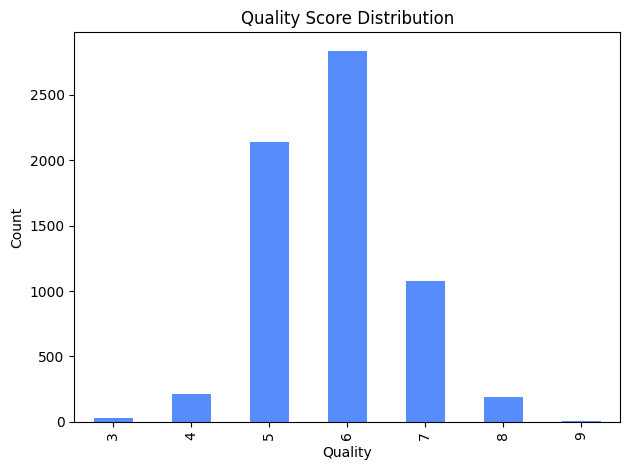

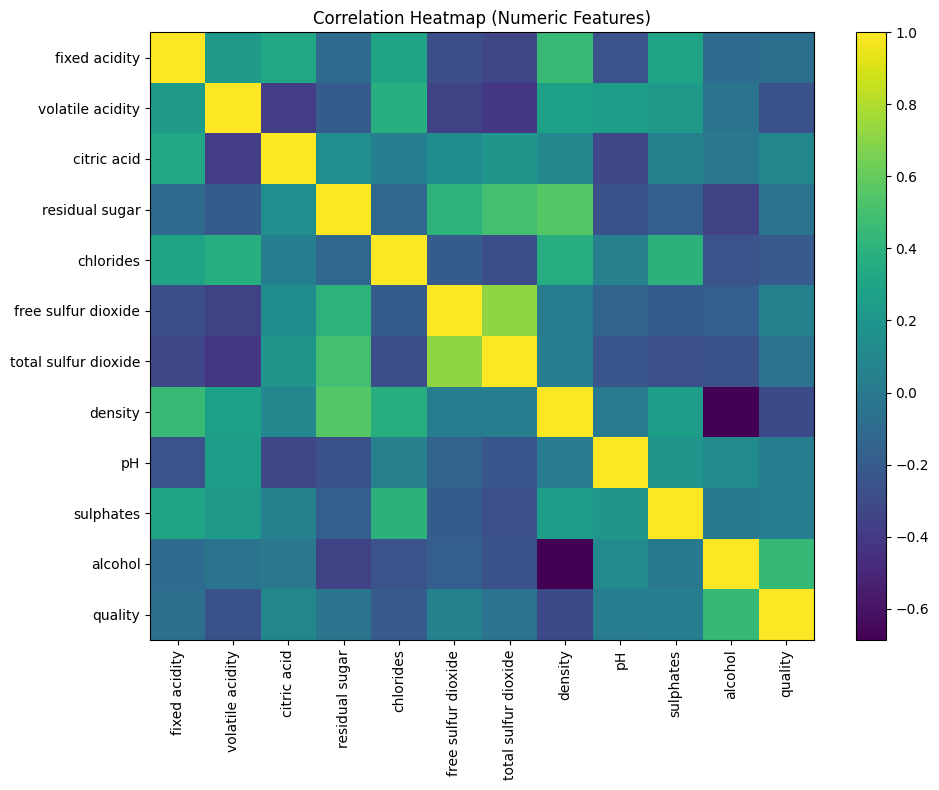

In [19]:
# Basic summary
summary = df.describe(include='all').transpose()
display(summary)

# Save summary
summary.to_csv(OUTPUT_DIR / 'eda_summary.csv')

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print('Missing values (should be 0 for this dataset):')
print(missing.head(20))
missing.to_csv(OUTPUT_DIR / 'missing_values.csv')

# Quality distribution
plt.figure()
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.title('Quality Score Distribution')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_distribution.png', dpi=150)
plt.show()

# Correlation heatmap (numeric only)
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

corr.to_csv(OUTPUT_DIR / 'correlation_matrix.csv')


In [20]:
# One-hot encode wine_type when both are present
work = pd.get_dummies(df, columns=['wine_type'], drop_first=True)

# Targets
work['good_wine'] = (work['quality'] >= 7).astype(int)

# Regression data
X_reg = work.drop(columns=['quality', 'good_wine'])
y_reg = work['quality'].astype(float)

# Classification data
X_clf = work.drop(columns=['quality', 'good_wine'])
y_clf = work['good_wine'].astype(int)

print('Regression X shape:', X_reg.shape)
print('Classification positive rate:', y_clf.mean())


Regression X shape: (6497, 12)
Classification positive rate: 0.19655225488687086


=== Regression: LinearRegression ===


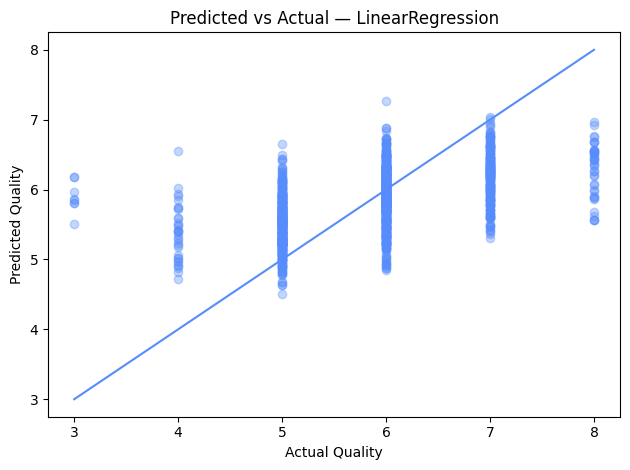

=== Regression: Ridge ===


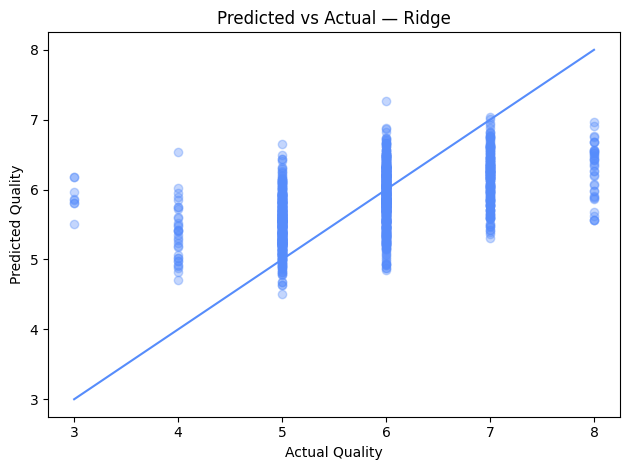

=== Regression: Lasso ===


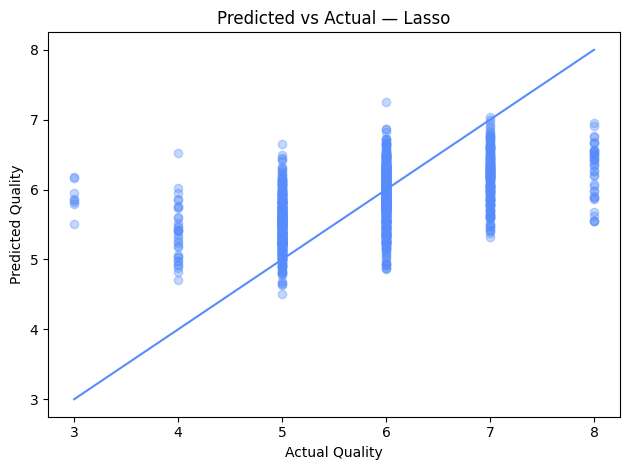

=== Regression: RandomForest ===


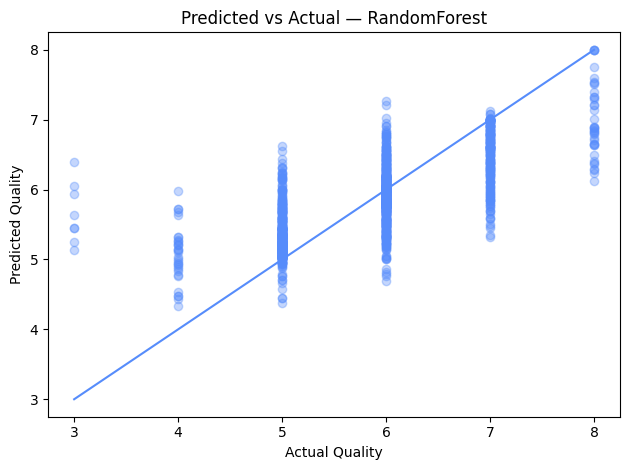

=== Regression: GradientBoosting ===


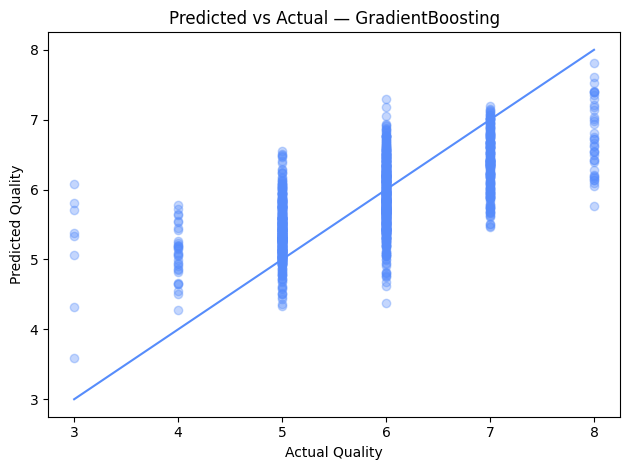

,model,cv_rmse,cv_mae,cv_r2,test_rmse,test_mae,test_r2,best_params
3,RandomForest,0.623484,0.452259,0.492057,0.587259,0.423892,0.540314,"{'model__max_depth': None, 'model__min_samples..."
4,GradientBoosting,0.677597,0.520328,0.399188,0.643850,0.503118,0.447451,"{'model__learning_rate': 0.1, 'model__max_dept..."
2,Lasso,0.734249,0.570200,0.294347,0.733548,0.565839,0.282770,{'model__alpha': 0.001}
1,Ridge,0.734184,0.569986,0.294451,0.733702,0.565799,0.282468,{'model__alpha': 10.0}
0,LinearRegression,0.734234,0.569954,0.294350,0.733842,0.565887,0.282195,{}


In [21]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# Train/test split (bin-stratified to preserve ordinal-ish target distribution)
# We bin y for stratification because quality is discrete and imbalanced.
try:
    y_bins = pd.qcut(y_reg, q=6, duplicates='drop')
    strat = y_bins.astype(str)
except ValueError:
    strat = y_reg.astype(str)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42, stratify=strat
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def eval_regression_model(name, pipeline, param_grid=None):
    # optional grid search on RMSE (via MSE scorer)
    if param_grid:
        gs = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            scoring='neg_mean_squared_error',
            cv=cv,
            n_jobs=-1
        )
        gs.fit(Xr_train, yr_train)
        best = gs.best_estimator_
        best_params = gs.best_params_
    else:
        best = pipeline.fit(Xr_train, yr_train)
        best_params = {}

    # CV MSE -> RMSE
    cv_res = cross_validate(
        best,
        Xr_train,
        yr_train,
        scoring={'mse': 'neg_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
        cv=cv,
        n_jobs=-1
    )
    cv_rmse = np.sqrt(-cv_res['test_mse'].mean())
    cv_mae = -cv_res['test_mae'].mean()
    cv_r2 = cv_res['test_r2'].mean()

    # Holdout test
    y_pred = best.predict(Xr_test)
    test_rmse = rmse(yr_test, y_pred)
    test_mae = float(mean_absolute_error(yr_test, y_pred))
    test_r2 = float(r2_score(yr_test, y_pred))

    # Plots
    plt.figure()
    plt.scatter(yr_test, y_pred, alpha=0.35)
    plt.xlabel('Actual Quality')
    plt.ylabel('Predicted Quality')
    plt.title(f'Predicted vs Actual — {name}')
    minv, maxv = float(min(yr_test.min(), y_pred.min())), float(max(yr_test.max(), y_pred.max()))
    plt.plot([minv, maxv], [minv, maxv])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'pred_vs_actual_{name}.png', dpi=150)
    plt.show()

    return {
        'model': name,
        'cv_rmse': float(cv_rmse),
        'cv_mae': float(cv_mae),
        'cv_r2': float(cv_r2),
        'test_rmse': float(test_rmse),
        'test_mae': float(test_mae),
        'test_r2': float(test_r2),
        'best_params': best_params,
        'estimator': best
    }

# Model definitions
models = []

models.append((
    'LinearRegression',
    Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    None
))

models.append((
    'Ridge',
    Pipeline([('scaler', StandardScaler()), ('model', Ridge(random_state=42))]),
    {'model__alpha': [0.1, 1.0, 10.0, 50.0]}
))

models.append((
    'Lasso',
    Pipeline([('scaler', StandardScaler()), ('model', Lasso(random_state=42, max_iter=10000))]),
    {'model__alpha': [0.001, 0.01, 0.1, 1.0]}
))

models.append((
    'RandomForest',
    Pipeline([('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]),
    {'model__max_depth': [None, 8, 16], 'model__min_samples_split': [2, 5, 10]}
))

models.append((
    'GradientBoosting',
    Pipeline([('model', GradientBoostingRegressor(random_state=42))]),
    {'model__n_estimators': [200, 400], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3]}
))

reg_results = []
reg_best_estimators = {}

for name, pipe, grid in models:
    print(f'=== Regression: {name} ===')
    res = eval_regression_model(name, pipe, grid)
    reg_results.append({k: v for k, v in res.items() if k not in {'estimator'}})
    reg_best_estimators[name] = res['estimator']

reg_results_df = pd.DataFrame(reg_results).sort_values('test_rmse')
reg_results_df.to_csv(OUTPUT_DIR / 'regression_model_results.csv', index=False)
reg_results_df


In [22]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def unwrap_estimator(estimator):
    """
    Handles Pipeline, GridSearchCV, and bare estimators.
    Returns the fitted final estimator (e.g., Ridge model or RandomForest model).
    """
    # If it's a GridSearchCV, pull out the fitted best_estimator_
    if hasattr(estimator, "best_estimator_"):
        estimator = estimator.best_estimator_

    # If it's a Pipeline, pull out the 'model' step
    if hasattr(estimator, "named_steps") and "model" in estimator.named_steps:
        return estimator.named_steps["model"]

    return estimator

def show_linear_coeffs(estimator, feature_names, top_n=10):
    model = unwrap_estimator(estimator)

    if hasattr(model, "coef_"):
        coefs = pd.Series(model.coef_, index=feature_names).sort_values(
            key=np.abs, ascending=False
        )
        print("\nTop coefficients:")
        print(coefs.head(top_n).to_string())

        out = OUTPUT_DIR / f"coefficients_{type(model).__name__}.csv"
        coefs.to_csv(out, header=["coefficient"])
        print(f"\nSaved full coefficients to: {out.resolve()}")
    else:
        print(f"No coefficients available for estimator type: {type(model).__name__}")

def show_tree_importance(estimator, feature_names, top_n=10):
    model = unwrap_estimator(estimator)

    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(
            ascending=False
        )
        print("\nTop importances:")
        print(imp.head(top_n).to_string())

        out = OUTPUT_DIR / f"feature_importance_{type(model).__name__}.csv"
        imp.to_csv(out, header=["importance"])
        print(f"\nSaved full importances to: {out.resolve()}")
    else:
        print(f"No feature_importances_ available for estimator type: {type(model).__name__}")

# Use the same feature names you used in training
feature_names = X_reg.columns

print("Top linear coefficients (Ridge):")
show_linear_coeffs(reg_best_estimators["Ridge"], feature_names, top_n=10)

print("\nTop feature importances (RandomForest):")
show_tree_importance(reg_best_estimators["RandomForest"], feature_names, top_n=10)


Top linear coefficients (Ridge):

Top coefficients:
density                -0.311586
residual sugar          0.300570
alcohol                 0.265782
volatile acidity       -0.249732
wine_type_white        -0.157786
fixed acidity           0.116120
sulphates               0.108762
pH                      0.086731
free sulfur dioxide     0.084402
total sulfur dioxide   -0.070040

Saved full coefficients to: C:\Users\morganmic\Downloads\outputs\coefficients_Ridge.csv

Top feature importances (RandomForest):

Top importances:
alcohol                 0.249757
volatile acidity        0.130494
free sulfur dioxide     0.087905
sulphates               0.076539
residual sugar          0.074676
total sulfur dioxide    0.071697
pH                      0.070037
chlorides               0.065936
density                 0.057495
citric acid             0.057197

Saved full importances to: C:\Users\morganmic\Downloads\outputs\feature_importance_RandomForestRegressor.csv


=== Classification: LogisticRegression ===
Accuracy : 0.7123
Precision: 0.3825
Recall   : 0.75
F1 Score : 0.5066
ROC AUC  : 0.8019
Confusion matrix: [[734 310]
 [ 64 192]]


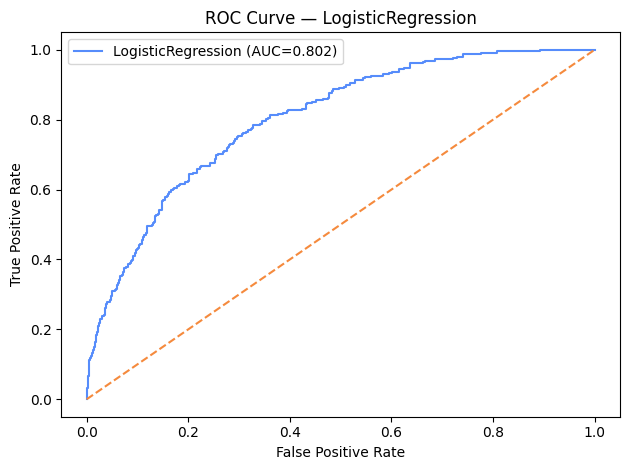

=== Classification: RandomForestClassifier ===
Accuracy : 0.8846
Precision: 0.8046
Recall   : 0.5469
F1 Score : 0.6512
ROC AUC  : 0.9142
Confusion matrix: [[1010   34]
 [ 116  140]]


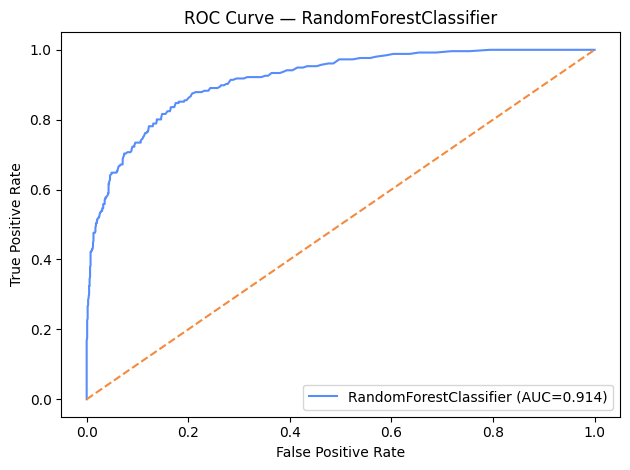

=== Classification: GradientBoostingClassifier ===
Accuracy : 0.8469
Precision: 0.6939
Recall   : 0.3984
F1 Score : 0.5062
ROC AUC  : 0.8593
Confusion matrix: [[999  45]
 [154 102]]


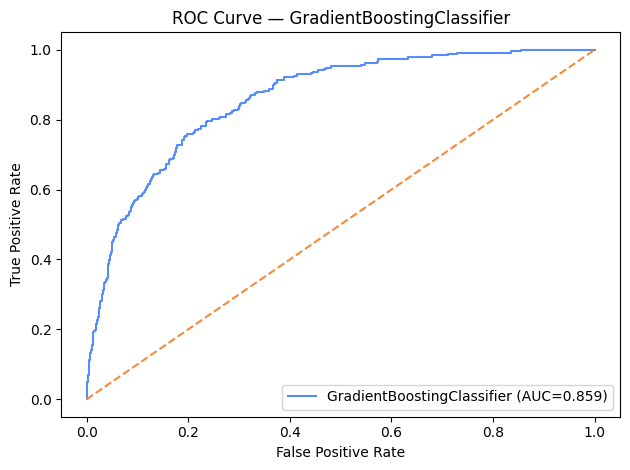

,model,accuracy,precision,recall,f1,roc_auc
1,RandomForestClassifier,0.884615,0.804598,0.546875,0.651163,0.914152
2,GradientBoostingClassifier,0.846923,0.693878,0.398438,0.506203,0.859341
0,LogisticRegression,0.712308,0.382470,0.750000,0.506596,0.801904


In [23]:
# Train/test split (stratified on class)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

def evaluate_classifier(name, model, plot_roc=True):
    model.fit(Xc_train, yc_train)
    y_pred = model.predict(Xc_test)

    # Probabilities for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(Xc_test)[:, 1]
    else:
        # Some models expose decision_function instead
        y_prob = model.decision_function(Xc_test)

    acc = accuracy_score(yc_test, y_pred)
    prec = precision_score(yc_test, y_pred, zero_division=0)
    rec = recall_score(yc_test, y_pred, zero_division=0)
    f1 = f1_score(yc_test, y_pred, zero_division=0)
    auc = roc_auc_score(yc_test, y_prob)
    cm = confusion_matrix(yc_test, y_pred)

    print(f'=== Classification: {name} ===')
    print('Accuracy :', round(acc, 4))
    print('Precision:', round(prec, 4))
    print('Recall   :', round(rec, 4))
    print('F1 Score :', round(f1, 4))
    print('ROC AUC  :', round(auc, 4))
    print('Confusion matrix:', cm)

    if plot_roc:
        fpr, tpr, _ = roc_curve(yc_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve — {name}')
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f'roc_{name}.png', dpi=150)
        plt.show()

    return {
        'model': name,
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'roc_auc': float(auc)
    }

# Models
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
])

rf_clf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

gb_clf = GradientBoostingClassifier(random_state=42)

clf_results = []
clf_results.append(evaluate_classifier('LogisticRegression', logreg))
clf_results.append(evaluate_classifier('RandomForestClassifier', rf_clf))
clf_results.append(evaluate_classifier('GradientBoostingClassifier', gb_clf))

clf_results_df = pd.DataFrame(clf_results).sort_values('roc_auc', ascending=False)
clf_results_df.to_csv(OUTPUT_DIR / 'classification_model_results.csv', index=False)
clf_results_df


In [24]:
best = reg_results_df.iloc[0]
print(f"Best regression model by test RMSE: {best['model']} (RMSE={best['test_rmse']:.3f})")

Best regression model by test RMSE: RandomForest (RMSE=0.587)
